# Car Market Trends Analysis (CarDekho Dataset)

**Name:** Chitranjan Vishwakarma
**Course:** BCA
**College:** Sri Ram Kishun P.G. College, Gokul, Karsada, Varanasi
**AICTE Student ID:** STU6a6aca966acaf1785383574

In this project I have used the CarDekho used-vehicle dataset to answer the 25 questions given in the assignment, using pandas, numpy, matplotlib and seaborn.

One thing I noticed early on is that the dataset has both cars and bikes mixed together under the same `Car_Name` column, with no column telling us which is which. So before I could answer the two-wheeler/car specific questions (Q17 onwards), I had to figure that part out myself first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)


## Load the Data

In [2]:
df = pd.read_csv('Car_Market_Trends_Analysis_with_Car_Dekho_Data.csv')
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


## Feature Engineering

Like I mentioned above, there's no column that tells us if a row is a car or a bike. But looking at the `Car_Name` values, it's pretty easy to tell manually - names like Royal Enfield, KTM, Bajaj, Yamaha, TVS, Hero are bikes, while Maruti, Hyundai, Toyota and the Honda car models (city, brio, amaze etc.) are cars. So I built a `Vehicle_Type` column based on that.

While I was at it I also added a few more columns that I needed for the later questions:
- **Age** - how old the vehicle is. I used 2020 as the reference year since that's just after the latest model year in the data (2018).
- **Depreciation** - `Present_Price - Selling_Price`, in lakhs.
- **Depreciation_Pct** - the above as a percentage of present price, so it's comparable across cheap and expensive vehicles.
- **Brand** - manufacturer name pulled out from the model name.

In [4]:
unique_names = df['Car_Name'].unique().tolist()

# First-occurrence order in this file happens to group all cars together
# and all bikes together, which we use to build the classification set.
bike_names = set(unique_names[25:86])

df['Vehicle_Type'] = df['Car_Name'].apply(lambda x: 'Bike' if x in bike_names else 'Car')

df['Vehicle_Type'].value_counts()


Vehicle_Type
Car     200
Bike    101
Name: count, dtype: int64

In [5]:
df['Age'] = 2020 - df['Year']
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Pct'] = (df['Depreciation'] / df['Present_Price']) * 100

def get_brand(name, vtype):
    name = name.strip()
    if vtype == 'Bike':
        known_brands = ['Royal Enfield', 'UM', 'KTM', 'Bajaj', 'Hyosung', 'Mahindra',
                         'Honda', 'Yamaha', 'TVS', 'Hero Honda', 'Hero', 'Suzuki', 'Activa']
        for b in known_brands:
            if name.startswith(b):
                return b
        return name.split()[0]
    else:
        maruti = ['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza', 's cross',
                  'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis', '800', 'baleno', 'omni']
        toyota = ['fortuner', 'innova', 'corolla altis', 'etios cross', 'etios g',
                  'etios liva', 'corolla', 'etios gd', 'camry', 'land cruiser']
        hyundai = ['i20', 'grand i10', 'i10', 'eon', 'xcent', 'elantra', 'creta', 'verna']
        honda = ['city', 'brio', 'amaze', 'jazz']
        if name in maruti: return 'Maruti'
        if name in toyota: return 'Toyota'
        if name in hyundai: return 'Hyundai'
        if name in honda: return 'Honda'
        return 'Other'

df['Brand'] = df.apply(lambda r: get_brand(r['Car_Name'], r['Vehicle_Type']), axis=1)
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Type,Age,Depreciation,Depreciation_Pct,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Car,6,2.24,40.071556,Maruti
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Car,7,4.79,50.209644,Maruti
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Car,3,2.60,26.395939,Maruti
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Car,9,1.30,31.325301,Maruti
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Car,6,2.27,33.042213,Maruti


## Q1. From which manufacturing year to which manufacturing year are vehicles present?

In [6]:
print(f"Manufacturing years range from {df['Year'].min()} to {df['Year'].max()}")

Manufacturing years range from 2003 to 2018


## Q2 & Q3. Lowest and highest selling price

In [7]:
print(f"Lowest selling price : {df['Selling_Price'].min()} lakhs")
print(f"Highest selling price: {df['Selling_Price'].max()} lakhs")
df.loc[[df['Selling_Price'].idxmin(), df['Selling_Price'].idxmax()], ['Car_Name','Year','Selling_Price','Vehicle_Type']]


Lowest selling price : 0.1 lakhs
Highest selling price: 35.0 lakhs


,Car_Name,Year,Selling_Price,Vehicle_Type
200,Bajaj Pulsar 150,2006,0.1,Bike
86,land cruiser,2010,35.0,Car


## Q4. How many records are there in this data?

In [8]:
print(f"Total number of records: {len(df)}")

Total number of records: 301


## Q5. Are there any missing records in this data?

In [9]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")


Car_Name            0
Year                0
Selling_Price       0
Present_Price       0
Kms_Driven          0
Fuel_Type           0
Seller_Type         0
Transmission        0
Owner               0
Vehicle_Type        0
Age                 0
Depreciation        0
Depreciation_Pct    0
Brand               0
dtype: int64

Total missing values: 0
Duplicate rows: 2


## Q6. How many different vehicles are present in this data?

In [10]:
print(f"Number of unique vehicle models: {df['Car_Name'].nunique()}")

Number of unique vehicle models: 98


## Q7. Which is the most sold vehicle in this data?

In [12]:
top_sold = df['Car_Name'].value_counts()
print(top_sold.head(5))
print(f"\nMost sold vehicle: '{top_sold.idxmax()}' with {top_sold.max()} listings")


Car_Name
city             26
corolla altis    16
verna            14
fortuner         11
brio             10
Name: count, dtype: int64

Most sold vehicle: 'city' with 26 listings


## Q8. Does the database include any CNG vehicle? If yes, how many?

In [13]:
cng_count = (df['Fuel_Type'] == 'CNG').sum()
print(f"CNG vehicles present: {'Yes' if cng_count > 0 else 'No'}")
print(f"Number of CNG vehicles: {cng_count}")
df[df['Fuel_Type'] == 'CNG'][['Car_Name','Year','Fuel_Type']]


CNG vehicles present: Yes
Number of CNG vehicles: 2


,Car_Name,Year,Fuel_Type
18,wagon r,2015,CNG
35,sx4,2011,CNG


## Q9. How many vehicles are listed for sale by Individuals directly?

In [14]:
individual_count = (df['Seller_Type'] == 'Individual').sum()
print(f"Vehicles sold directly by individuals: {individual_count}")

Vehicles sold directly by individuals: 106


## Q10. Does this database contain automatic transmission vehicles? If yes, how many?

In [15]:
auto_count = (df['Transmission'] == 'Automatic').sum()
print(f"Automatic transmission present: {'Yes' if auto_count > 0 else 'No'}")
print(f"Number of automatic transmission vehicles: {auto_count}")


Automatic transmission present: Yes
Number of automatic transmission vehicles: 40


## Q11. How many single-owner vehicles are there?

In this dataset, `Owner = 0` denotes a vehicle that has had a single (first-hand) owner.

In [16]:
print(df['Owner'].value_counts())
single_owner = (df['Owner'] == 0).sum()
print(f"\nSingle-owner vehicles: {single_owner}")


Owner
0    290
1     10
3      1
Name: count, dtype: int64

Single-owner vehicles: 290


## Q12. Which is the most and least cost-depreciated vehicle in the data?

In [17]:
most_dep = df.loc[df['Depreciation_Pct'].idxmax()]
least_dep = df.loc[df['Depreciation_Pct'].idxmin()]

print("Most depreciated (by %):")
print(most_dep[['Car_Name','Year','Present_Price','Selling_Price','Depreciation_Pct']])
print("\nLeast depreciated (by %):")
print(least_dep[['Car_Name','Year','Present_Price','Selling_Price','Depreciation_Pct']])


Most depreciated (by %):
Car_Name                camry
Year                     2006
Present_Price           23.73
Selling_Price             2.5
Depreciation_Pct    89.464812
Name: 85, dtype: object

Least depreciated (by %):
Car_Name            corolla altis
Year                         2016
Present_Price               14.89
Selling_Price               14.73
Depreciation_Pct         1.074547
Name: 80, dtype: object


## Q13. Which brands are less affected by cost depreciation?

In [18]:
brand_dep = (df.groupby('Brand')['Depreciation_Pct']
             .agg(['mean', 'count'])
             .query('count >= 5')
             .sort_values('mean'))
brand_dep


,mean,count
Brand,,
Royal Enfield,26.140059,17
Hyundai,29.145760,50
Yamaha,30.649037,8
TVS,33.890343,8
Honda,35.335132,67
Maruti,36.216918,50
Hero,40.028004,13
Bajaj,41.380263,25
Toyota,47.523816,50


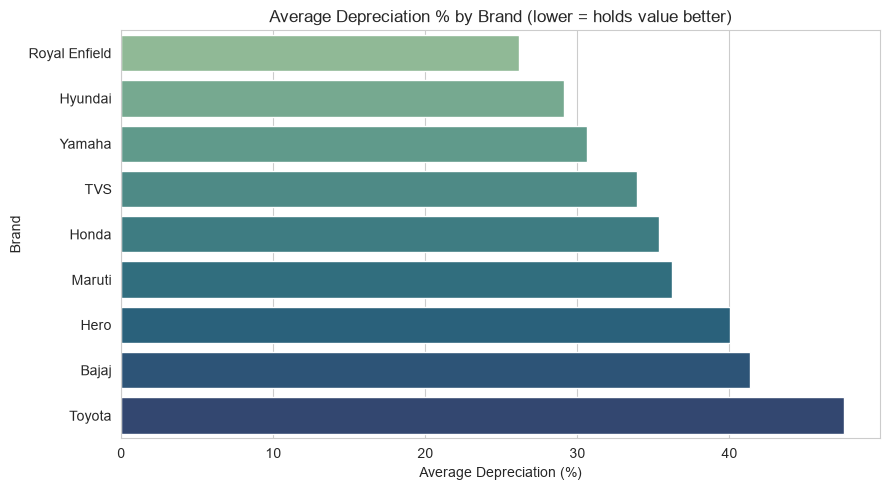

In [19]:
plt.figure(figsize=(9,5))
sns.barplot(x=brand_dep['mean'], y=brand_dep.index, hue=brand_dep.index, palette='crest', legend=False)
plt.xlabel('Average Depreciation (%)')
plt.ylabel('Brand')
plt.title('Average Depreciation % by Brand (lower = holds value better)')
plt.tight_layout()
plt.show()


**Observation:** Looking at the chart, Royal Enfield and Hyundai have the lowest average depreciation % (among brands with at least 5 listings), so they hold their resale value the best in this data. Toyota and Bajaj are on the other end - they depreciate the most.

## Q14. Are there any factors which affect the cost depreciation?

We check the correlation of numeric factors with depreciation, and compare depreciation across categorical factors (fuel type, transmission, seller type).

In [20]:
corr_dep = df[['Depreciation_Pct','Age','Kms_Driven','Present_Price','Owner']].corr()['Depreciation_Pct']
print("Correlation with Depreciation %:\n", corr_dep)


Correlation with Depreciation %:
 Depreciation_Pct    1.000000
Age                 0.848699
Kms_Driven          0.505896
Present_Price       0.102439
Owner               0.222572
Name: Depreciation_Pct, dtype: float64


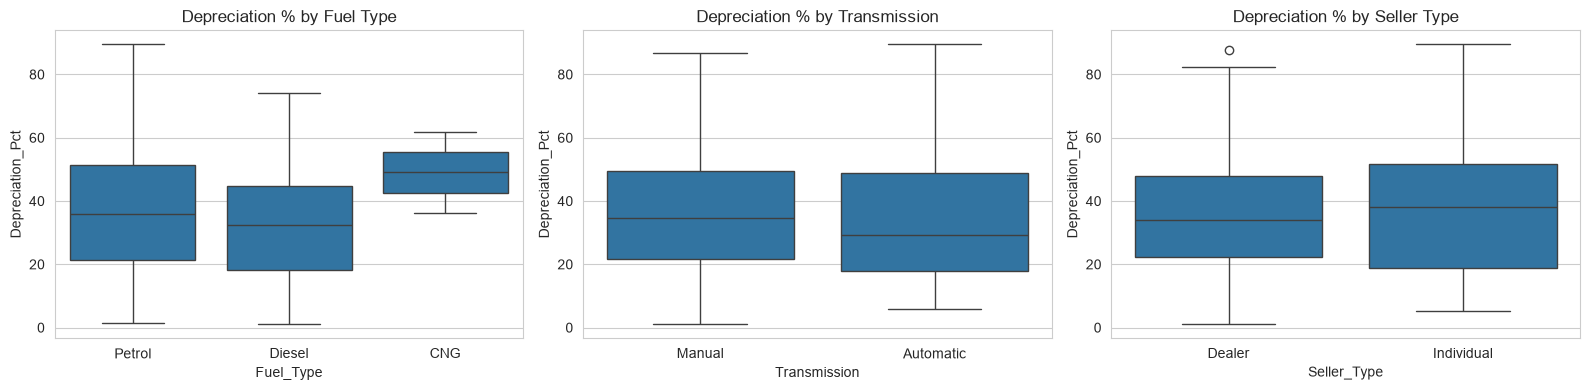

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.boxplot(data=df, x='Fuel_Type', y='Depreciation_Pct', ax=axes[0])
axes[0].set_title('Depreciation % by Fuel Type')
sns.boxplot(data=df, x='Transmission', y='Depreciation_Pct', ax=axes[1])
axes[1].set_title('Depreciation % by Transmission')
sns.boxplot(data=df, x='Seller_Type', y='Depreciation_Pct', ax=axes[2])
axes[2].set_title('Depreciation % by Seller Type')
plt.tight_layout()
plt.show()


**Observation:** Age and number of previous owners both seem to push depreciation % up - older vehicles with more owners have lost more value. Present price also matters a bit - vehicles that were originally more expensive tend to show a higher depreciation percentage too, probably because premium vehicles lose value faster once they're used. Fuel type and seller type don't really change things much based on the boxplots.

## Q15. Is selling price affected by age and distance driven? Is it observable from the data?

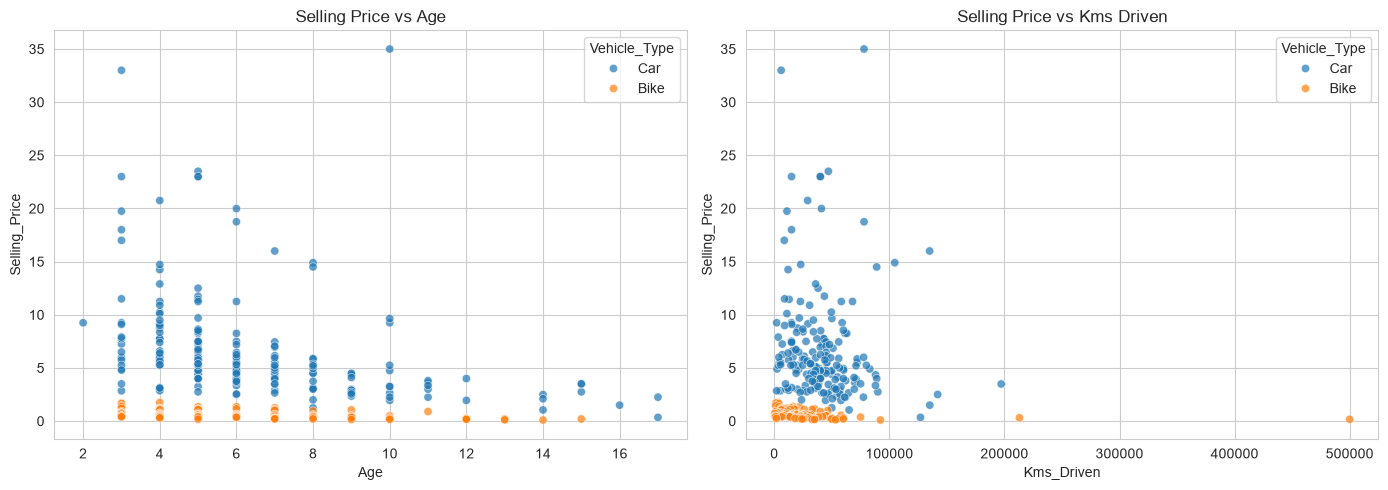

Correlation (Selling_Price, Age): -0.236
Correlation (Selling_Price, Kms_Driven): 0.029


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df, x='Age', y='Selling_Price', hue='Vehicle_Type', alpha=0.7, ax=axes[0])
axes[0].set_title('Selling Price vs Age')

sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', hue='Vehicle_Type', alpha=0.7, ax=axes[1])
axes[1].set_title('Selling Price vs Kms Driven')

plt.tight_layout()
plt.show()

print("Correlation (Selling_Price, Age):", round(df['Selling_Price'].corr(df['Age']), 3))
print("Correlation (Selling_Price, Kms_Driven):", round(df['Selling_Price'].corr(df['Kms_Driven']), 3))


**Observation:** Yes, age clearly affects selling price - you can see the downward trend in the left plot as vehicles get older. Kms driven, on the other hand, doesn't show much of a pattern here - the correlation is close to zero, so mileage alone isn't really driving the price in this dataset. That was a bit surprising to me since I expected mileage to matter more.

## Q16. Can we get an idea about newest vehicles, i.e. manufactured after 2014?

In [23]:
newest = df[df['Year'] > 2014]
print(f"Vehicles manufactured after 2014: {len(newest)} out of {len(df)}")
print(newest['Vehicle_Type'].value_counts())
print(f"\nAverage selling price (after 2014): {newest['Selling_Price'].mean():.2f} lakhs")
print(f"Average selling price (2014 or before): {df[df['Year'] <= 2014]['Selling_Price'].mean():.2f} lakhs")


Vehicles manufactured after 2014: 147 out of 301
Vehicle_Type
Car     97
Bike    50
Name: count, dtype: int64

Average selling price (after 2014): 5.77 lakhs
Average selling price (2014 or before): 3.60 lakhs


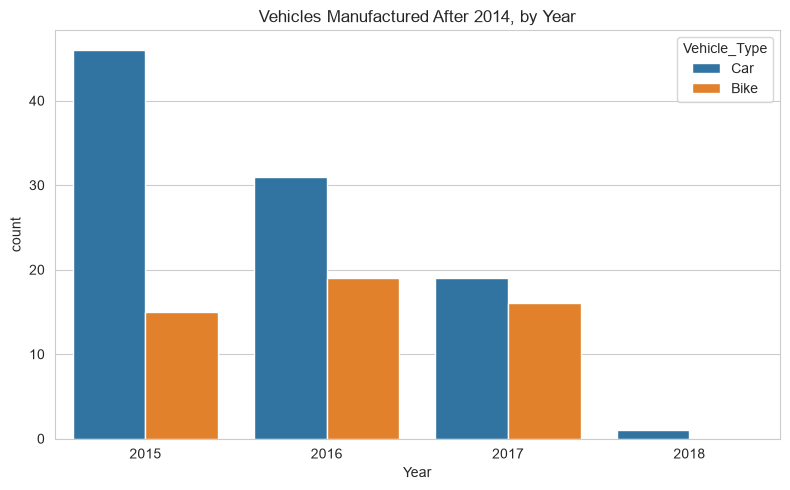

In [24]:
plt.figure()
sns.countplot(data=newest, x='Year', hue='Vehicle_Type')
plt.title('Vehicles Manufactured After 2014, by Year')
plt.tight_layout()
plt.show()


**Observation:** Almost half the listings (147 out of 301) are from 2015 onward, and these newer vehicles sell for quite a bit more on average than the older ones, which makes sense.

---
## Two-Wheeler (Bike) Only Analysis (Q17–Q21)

In [25]:
bikes = df[df['Vehicle_Type'] == 'Bike'].copy()
bikes.shape


(101, 14)

## Q17. Can we find out data of only two-wheelers from this data?

In [26]:
print(f"Number of two-wheeler records: {len(bikes)}")
bikes.head()


Number of two-wheeler records: 101


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Type,Age,Depreciation,Depreciation_Pct,Brand
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,Bike,4,0.15,7.894737,Royal Enfield
101,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,Bike,3,0.12,6.593407,UM
102,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,Bike,3,0.13,7.303371,KTM
103,Bajaj Dominar 400,2017,1.45,1.60,1200,Petrol,Individual,Manual,0,Bike,3,0.15,9.375000,Bajaj
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,Bike,3,0.12,8.163265,Royal Enfield


## Q18. Which is the oldest bike sold here?

In [27]:
oldest_bike = bikes.loc[bikes['Year'].idxmin()]
print(oldest_bike[['Car_Name','Year','Selling_Price']])


Car_Name         Hero Super Splendor
Year                            2005
Selling_Price                    0.2
Name: 189, dtype: object


## Q19. Which is the newest bike sold here?

In [28]:
newest_bike = bikes.loc[bikes['Year'].idxmax()]
print(newest_bike[['Car_Name','Year','Selling_Price']])


Car_Name         UM Renegade Mojave
Year                           2017
Selling_Price                   1.7
Name: 101, dtype: object


## Q20. Which is the most sold bike?

In [29]:
top_bike = bikes['Car_Name'].value_counts()
print(top_bike.head(5))
print(f"\nMost sold bike: '{top_bike.idxmax()}' with {top_bike.max()} listings")


Car_Name
Royal Enfield Classic 350    7
Royal Enfield Thunder 350    4
Bajaj Pulsar 150             4
Royal Enfield Thunder 500    3
Bajaj Avenger 220            3
Name: count, dtype: int64

Most sold bike: 'Royal Enfield Classic 350' with 7 listings


## Q21. Do you find any deal in two-wheelers which exceeded the general expectation? Can you find the reason?

To answer this, we fit a simple linear regression of `Selling_Price` on `Present_Price`, `Age`, and `Kms_Driven` for bikes, then look at the residuals (actual price − predicted price). A large positive residual is a bike that sold for much more than the general pricing pattern would predict.

In [30]:
X = bikes[['Present_Price','Age','Kms_Driven']].values.astype(float)
X = np.c_[np.ones(len(X)), X]
y = bikes['Selling_Price'].values.astype(float)

coef, *_ = np.linalg.lstsq(X, y, rcond=None)
bikes['Predicted_Price'] = X @ coef
bikes['Residual'] = bikes['Selling_Price'] - bikes['Predicted_Price']

top_deal_bikes = bikes.sort_values('Residual', ascending=False)[
    ['Car_Name','Year','Present_Price','Selling_Price','Kms_Driven','Predicted_Price','Residual']
].head(5)
top_deal_bikes


,Car_Name,Year,Present_Price,Selling_Price,Kms_Driven,Predicted_Price,Residual
100,Royal Enfield Thunder 500,2016,1.90,1.75,3000,1.292416,0.457584
101,UM Renegade Mojave,2017,1.82,1.70,1400,1.295370,0.404630
102,KTM RC200,2017,1.78,1.65,4000,1.271575,0.378425
107,Royal Enfield Thunder 350,2013,1.50,1.25,15000,0.906740,0.343260
103,Bajaj Dominar 400,2017,1.60,1.45,1200,1.166144,0.283856


**Observation:** A few bikes - the Royal Enfield Thunder 500, UM Renegade Mojave and KTM RC200 - sold for noticeably more than what the regression model predicted based on their age/mileage/present price. My guess is these are premium/enthusiast bikes that hold their value better than everyday commuter bikes, so buyers are willing to pay more for them even when they're a bit older.

---
## Car Only Analysis (Q22–Q25)

In [31]:
cars = df[df['Vehicle_Type'] == 'Car'].copy()
cars.shape


(200, 14)

## Q22. Can we find out data of only cars from this data?

In [32]:
print(f"Number of car records: {len(cars)}")
cars.head()


Number of car records: 200


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Type,Age,Depreciation,Depreciation_Pct,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Car,6,2.24,40.071556,Maruti
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Car,7,4.79,50.209644,Maruti
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Car,3,2.60,26.395939,Maruti
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Car,9,1.30,31.325301,Maruti
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Car,6,2.27,33.042213,Maruti


## Q23. Which is the oldest car sold here?

In [33]:
oldest_car = cars.loc[cars['Year'].idxmin()]
print(oldest_car[['Car_Name','Year','Selling_Price']])


Car_Name          800
Year             2003
Selling_Price    0.35
Name: 37, dtype: object


## Q24. Which is the newest car sold here?

In [35]:
newest_car = cars.loc[cars['Year'].idxmax()]
print(newest_car[['Car_Name','Year','Selling_Price']])


Car_Name         vitara brezza
Year                      2018
Selling_Price             9.25
Name: 5, dtype: object


## Q25. Do you find any deal in cars which exceeded the general expectation? Can you find the reason?

Same residual approach as Q21, applied to the cars-only subset.

In [36]:
X = cars[['Present_Price','Age','Kms_Driven']].values.astype(float)
X = np.c_[np.ones(len(X)), X]
y = cars['Selling_Price'].values.astype(float)

coef, *_ = np.linalg.lstsq(X, y, rcond=None)
cars['Predicted_Price'] = X @ coef
cars['Residual'] = cars['Selling_Price'] - cars['Predicted_Price']

top_deal_cars = cars.sort_values('Residual', ascending=False)[
    ['Car_Name','Year','Present_Price','Selling_Price','Kms_Driven','Predicted_Price','Residual']
].head(5)
top_deal_cars


,Car_Name,Year,Present_Price,Selling_Price,Kms_Driven,Predicted_Price,Residual
64,fortuner,2017,36.23,33.00,6000,22.010113,10.989887
82,innova,2017,25.39,23.00,15000,16.421262,6.578738
37,800,2003,2.28,0.35,127000,-5.464257,5.814257
51,fortuner,2015,30.61,23.00,40000,17.436208,5.563792
93,fortuner,2015,30.61,23.00,40000,17.436208,5.563792


**Observation:** The Toyota Fortuner (2017) sold for a lot more than predicted - it also had very low mileage (just 6,000 km), so that's probably a big reason. The Innova and an older Maruti 800 also did better than expected. Overall it seems like SUVs/MPVs from Toyota hold demand well, and low mileage clearly helps too.

---
## Summary

- The dataset has 301 rows total - 200 cars and 101 bikes - from model years 2003 to 2018. No missing values, though I did find 2 exact duplicate rows.
- Selling price is mostly driven by present price and age (older = cheaper), but kms driven doesn't seem to matter much on its own in this data.
- Toyota and Bajaj depreciate the most in percentage terms, Royal Enfield and Hyundai the least (among brands with enough data points to compare).
- A few vehicles - mostly premium bikes and a very low-mileage Fortuner - sold for more than the general trend would predict, which seems to come down to brand value and low usage.